In [1]:
import os
from google.colab import files

if not os.path.exists('/content/kaggle.json'):
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Downloading Tomato Leaf Disease YOLOv8 Dataset...")
!kaggle datasets download -d vasantharank/tomato-leaf-disease-detection-yolov8-dataset

print("Extracting...")
!unzip -q tomato-leaf-disease-detection-yolov8-dataset.zip -d /content/data/

if os.path.exists('tomato-leaf-disease-detection-yolov8-dataset.zip'):
    os.remove('tomato-leaf-disease-detection-yolov8-dataset.zip')

print("Done!  Dataset ready at: /content/data/")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/vasantharank/tomato-leaf-disease-detection-yolov8-dataset
License(s): CC-BY-NC-SA-4.0
100% 732M/732M [00:44<00:00, 17.4MB/s]

Extracting...
Done!  Dataset ready at: /content/data/


In [2]:
import os

root = '/content/data'
for dirpath, dirnames, filenames in os.walk(root):
    level   = dirpath.replace(root, '').count(os.sep)
    indent  = '  ' * level
    print(f"{indent}{os.path.basename(dirpath)}/")
    if level < 3:
        sub = '  ' * (level + 1)
        for f in sorted(filenames)[:4]:
            print(f"{sub}{f}")
        if len(filenames) > 4:
            print(f"{sub}... ({len(filenames)} files total)")

data/
  data.yaml
  test/
    labels/
      000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL-Leaf-259_1_JPG.rf.f8c51bfd0522f888182e95fecc31d33e.txt
      0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly_B-8389_JPG.rf.749b258fde3efc9d2eaac8dabbe7cadf.txt
      0034a551-9512-44e5-ba6c-827f85ecc688___RS_Erly_B-9432_JPG.rf.561f90f6755c420a71bfc1f76f071d4d.txt
      003944fc-3b99-4a0f-9ed4-0e07352fd8b3___RS_HL-9844_JPG.rf.c139f0a55804f60866bc233f6383678d.txt
      ... (1051 files total)
    images/
      000146ff-92a4-4db6-90ad-8fce2ae4fddd___GH_HL-Leaf-259_1_JPG.rf.f8c51bfd0522f888182e95fecc31d33e.jpg
      0012b9d2-2130-4a06-a834-b1f3af34f57e___RS_Erly_B-8389_JPG.rf.749b258fde3efc9d2eaac8dabbe7cadf.jpg
      0034a551-9512-44e5-ba6c-827f85ecc688___RS_Erly_B-9432_JPG.rf.561f90f6755c420a71bfc1f76f071d4d.jpg
      003944fc-3b99-4a0f-9ed4-0e07352fd8b3___RS_HL-9844_JPG.rf.c139f0a55804f60866bc233f6383678d.jpg
      ... (1051 files total)
  train/
    labels/
      000bf685-b305-408b-91f4-37030f8e62db_

In [3]:
import os
import cv2
import glob
import numpy as np
from tqdm import tqdm

PROC_IMG_DIR  = '/content/data/processed/images'
PROC_MASK_DIR = '/content/data/processed/masks'
os.makedirs(PROC_IMG_DIR, exist_ok= True)
os.makedirs(PROC_MASK_DIR, exist_ok= True)


def find_label(img_path):
    candidate = img_path.replace('/images/', '/labels/')
    candidate = os.path.splitext(candidate)[0] + '.txt'
    if os.path.exists(candidate):
        return candidate
    candidate = os.path.splitext(img_path)[0] + '.txt'
    if os.path.exists(candidate):
        return candidate
    return None


def yolo_to_mask(label_path, img_h, img_w):
    mask = np.zeros((img_h, img_w), dtype=np.uint8)
    if label_path is None or not os.path.exists(label_path):
        return mask

    with open(label_path) as f:
        lines = [ln.strip() for ln in f if ln.strip()]

    for line in lines:
        vals   = list(map(float, line.split()))
        coords = vals[1:]

        if len(coords) == 4:
            cx, cy, w, h = coords
            x1 = max(0, int((cx - w / 2) * img_w))
            y1 = max(0, int((cy - h / 2) * img_h))
            x2 = min(img_w, int((cx + w / 2) * img_w))
            y2 = min(img_h, int((cy + h / 2) * img_h))
            cv2.rectangle(mask, (x1, y1), (x2, y2), 255, cv2.FILLED)

        elif len(coords) >= 6 and len(coords) % 2 == 0:
            pts = np.array(coords, dtype=np.float32).reshape(-1, 2)
            pts[:, 0] *= img_w
            pts[:, 1] *= img_h
            cv2.fillPoly(mask, [pts.astype(np.int32)], 255)

    return mask


IMAGE_EXTS = ('.jpg', '.jpeg', '.png')
image_paths = sorted(p for p in glob.glob('/content/data/**/*', recursive=True) if p.lower().endswith(IMAGE_EXTS))
print(f"Images found: {len(image_paths)}")

for p in image_paths:
    lp = find_label(p)
    if lp:
        with open(lp) as f:
            sample = f.readline().strip().split()
        if len(sample) > 1:
            n = len(sample) - 1
            fmt = "POLYGON" if n > 4 else "BOUNDING BOX"
            print(f"Label format: {fmt}  ({n} coordinate values per annotation)")
            print(f"Sample line : {' '.join(sample)}")
            break

converted, skipped = 0, 0

for idx, img_path in enumerate(tqdm(image_paths)):
    img = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue

    img_h, img_w = img.shape[:2]
    lbl_path = find_label(img_path)
    mask     = yolo_to_mask(lbl_path, img_h, img_w)

    base     = f"img_{idx:06d}"
    cv2.imwrite(os.path.join(PROC_IMG_DIR,  base + '.jpg'), img)
    cv2.imwrite(os.path.join(PROC_MASK_DIR, base + '.png'), mask)
    converted += 1

print(f"\nConverted : {converted}")
print(f"Skipped   : {skipped}")
print(f"Images -> {PROC_IMG_DIR}")
print(f"Masks  -> {PROC_MASK_DIR}")

Images found: 10853
Label format: BOUNDING BOX  (4 coordinate values per annotation)
Sample line : 8 0.4953125 0.471875 0.74765625 0.8578125


100%|██████████| 10853/10853 [01:16<00:00, 142.70it/s]


Converted : 10853
Skipped   : 0
Images -> /content/data/processed/images
Masks  -> /content/data/processed/masks


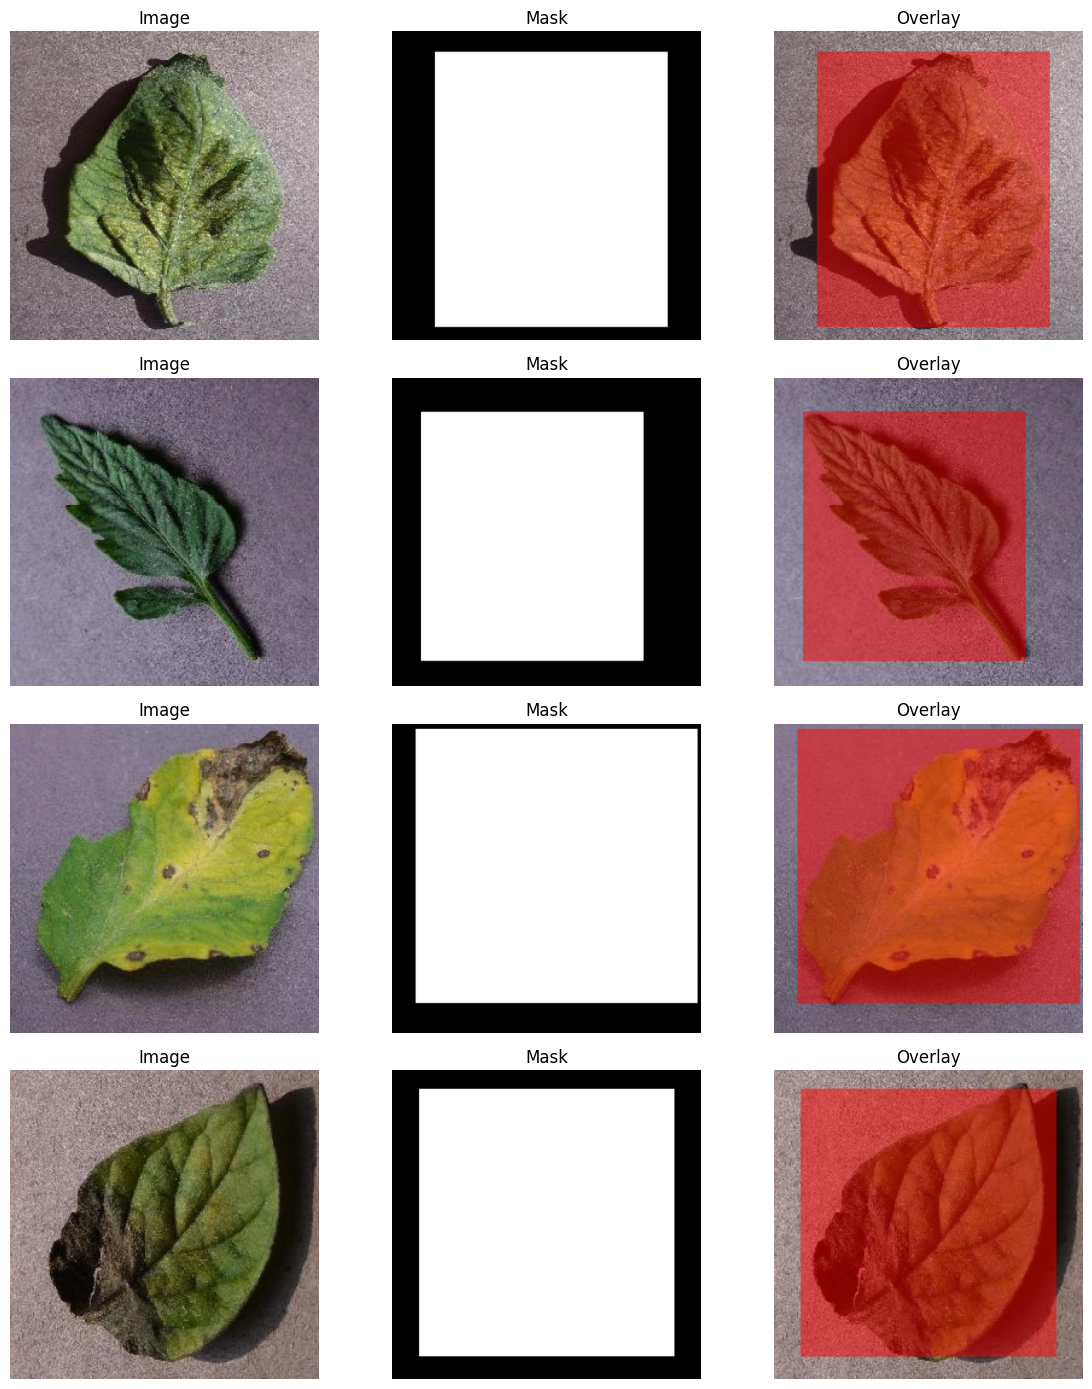

In [4]:
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

proc_imgs = sorted(os.listdir(PROC_IMG_DIR))
samples = random.sample(proc_imgs, min(4, len(proc_imgs)))

fig, axes = plt.subplots(len(samples), 3, figsize=(12, 3.5 * len(samples)))
if len(samples) == 1:
    axes = np.expand_dims(axes, 0)

for i, name in enumerate(samples):
    base = os.path.splitext(name)[0]
    img = cv2.cvtColor(cv2.imread(os.path.join(PROC_IMG_DIR,  name)), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(PROC_MASK_DIR, base + '.png'), cv2.IMREAD_GRAYSCALE)
    img_r = cv2.resize(img, (512, 512))
    msk_r = cv2.resize(mask, (512, 512))

    overlay = img_r.copy()
    overlay[msk_r > 0] = overlay[msk_r > 0] * 0.5 + np.array([255, 0, 0]) * 0.5

    axes[i, 0].imshow(img_r); axes[i, 0].set_title("Image"); axes[i, 0].axis("off")
    axes[i, 1].imshow(msk_r, cmap="gray"); axes[i, 1].set_title("Mask"); axes[i, 1].axis("off")
    axes[i, 2].imshow(overlay.astype(np.uint8)); axes[i, 2].set_title("Overlay"); axes[i, 2].axis("off")

plt.tight_layout()
plt.show()

In [5]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2

all_images = sorted(os.listdir("/content/data/processed/images"))
train_imgs, val_imgs = train_test_split(all_images, test_size= 0.2, random_state= 42)
print(f"Train: {len(train_imgs)}  |  Val: {len(val_imgs)}")

# GaussNoise removed -- too aggressive for leaf textures
train_transform = A.Compose([A.Resize(512, 512), A.HorizontalFlip(p=0.5), A.VerticalFlip(p=0.5), A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.15, rotate_limit=30, p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.5), A.CLAHE(clip_limit=4.0, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()])

val_transform = A.Compose([A.Resize(512, 512), A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)), ToTensorV2()])


class LeafDataset(Dataset):
    def __init__(self, img_dir, mask_dir, img_list, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.img_list  = img_list
        self.transform = transform

    def __len__(self):
        return len(self.img_list)

    def __getitem__(self, idx):
        img_name = self.img_list[idx]
        base = os.path.splitext(img_name)[0]

        img = cv2.imread(os.path.join(self.img_dir,  img_name))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(os.path.join(self.mask_dir, base + '.png'), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise FileNotFoundError(f"Mask not found for {img_name}")

        mask = (mask > 0).astype(np.float32)

        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask']

        return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

img_dir = '/content/data/processed/images'
mask_dir = '/content/data/processed/masks'
train_ds = LeafDataset(img_dir, mask_dir, train_imgs, train_transform)
val_ds   = LeafDataset(img_dir, mask_dir, val_imgs,   val_transform)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2)

Train: 8682  |  Val: 2171


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [6]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 16.3 MB/s eta 0:00:00


In [7]:
import torch
import segmentation_models_pytorch as smp

model = smp.UnetPlusPlus(encoder_name= 'efficientnet-b3', encoder_weights= 'imagenet', in_channels= 3, classes= 1)

dice_loss  = smp.losses.DiceLoss(mode= 'binary')
focal_loss = smp.losses.FocalLoss(mode= 'binary')

def loss_fn(pred, target):
    return dice_loss(pred, target) + focal_loss(pred, target)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
print(f"Training on: {device}")


def iou_score(pred, mask):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * mask).sum()
    union = pred.sum() + mask.sum() - intersection
    return (intersection + 1e-6) / (union + 1e-6)


def dice_score(pred, mask):
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()
    intersection = (pred * mask).sum()
    return (2 * intersection + 1e-6) / (pred.sum() + mask.sum() + 1e-6)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

Training on: cuda


In [8]:
from tqdm import tqdm

best_iou = 0.0
EPOCHS   = 5

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for images, masks in tqdm(train_loader, desc=f'Epoch {epoch+1:02d}/{EPOCHS} [train]'):
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()

    model.eval()
    val_iou = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f'Epoch {epoch+1:02d}/{EPOCHS} [val]'):
            images = images.to(device)
            masks = masks.to(device)
            out = model(images)
            val_iou  += iou_score(out, masks).item()
            val_dice += dice_score(out, masks).item()

    avg_iou  = val_iou  / len(val_loader)
    avg_dice = val_dice / len(val_loader)

    print(
        f'Epoch {epoch+1:02d}/{EPOCHS} | '
        f'Loss: {train_loss/len(train_loader):.4f} | '
        f'IoU: {avg_iou:.4f} | '
        f'Dice: {avg_dice:.4f}'
    )

    if avg_iou > best_iou:
        best_iou = avg_iou
        torch.save(model.state_dict(), 'leaf_seg.pth')
        print(f'  Best model saved (IoU: {best_iou:.4f})')

Epoch 01/5 [train]:   0%|          | 0/1086 [00:00<?, ?it/s]/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
Epoch 01/5 [val]:   0%|          | 0/272 [00:00<?, ?it/s]/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.fl

Epoch 01/5 | Loss: 0.2194 | IoU: 0.9050 | Dice: 0.9494
  Best model saved (IoU: 0.9050)


Epoch 02/5 [train]:   0%|          | 0/1086 [00:00<?, ?it/s]/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
Epoch 02/5 [val]:   0%|          | 0/272 [00:00<?, ?it/s]/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.fl

Epoch 02/5 | Loss: 0.1737 | IoU: 0.9135 | Dice: 0.9541
  Best model saved (IoU: 0.9135)


Epoch 03/5 [train]:   0%|          | 0/1086 [00:00<?, ?it/s]/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
Epoch 03/5 [val]:   0%|          | 0/272 [00:00<?, ?it/s]/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.fl

Epoch 03/5 | Loss: 0.1609 | IoU: 0.9142 | Dice: 0.9545
  Best model saved (IoU: 0.9142)


Epoch 04/5 [train]:   0%|          | 0/1086 [00:00<?, ?it/s]/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
Epoch 04/5 [val]:   0%|          | 0/272 [00:00<?, ?it/s]/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.fl

Epoch 04/5 | Loss: 0.1518 | IoU: 0.9163 | Dice: 0.9556
  Best model saved (IoU: 0.9163)


Epoch 05/5 [train]:   0%|          | 0/1086 [00:00<?, ?it/s]/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
Epoch 05/5 [val]:   0%|          | 0/272 [00:00<?, ?it/s]/tmp/ipykernel_1172/4121480590.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return img, torch.tensor(mask, dtype=torch.fl

Epoch 05/5 | Loss: 0.1452 | IoU: 0.9190 | Dice: 0.9571
  Best model saved (IoU: 0.9190)


In [9]:
from google.colab import files

weight_path = "leaf_seg.pth"
files.download(weight_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Loaded weights from: tomato_disease_seg.pth


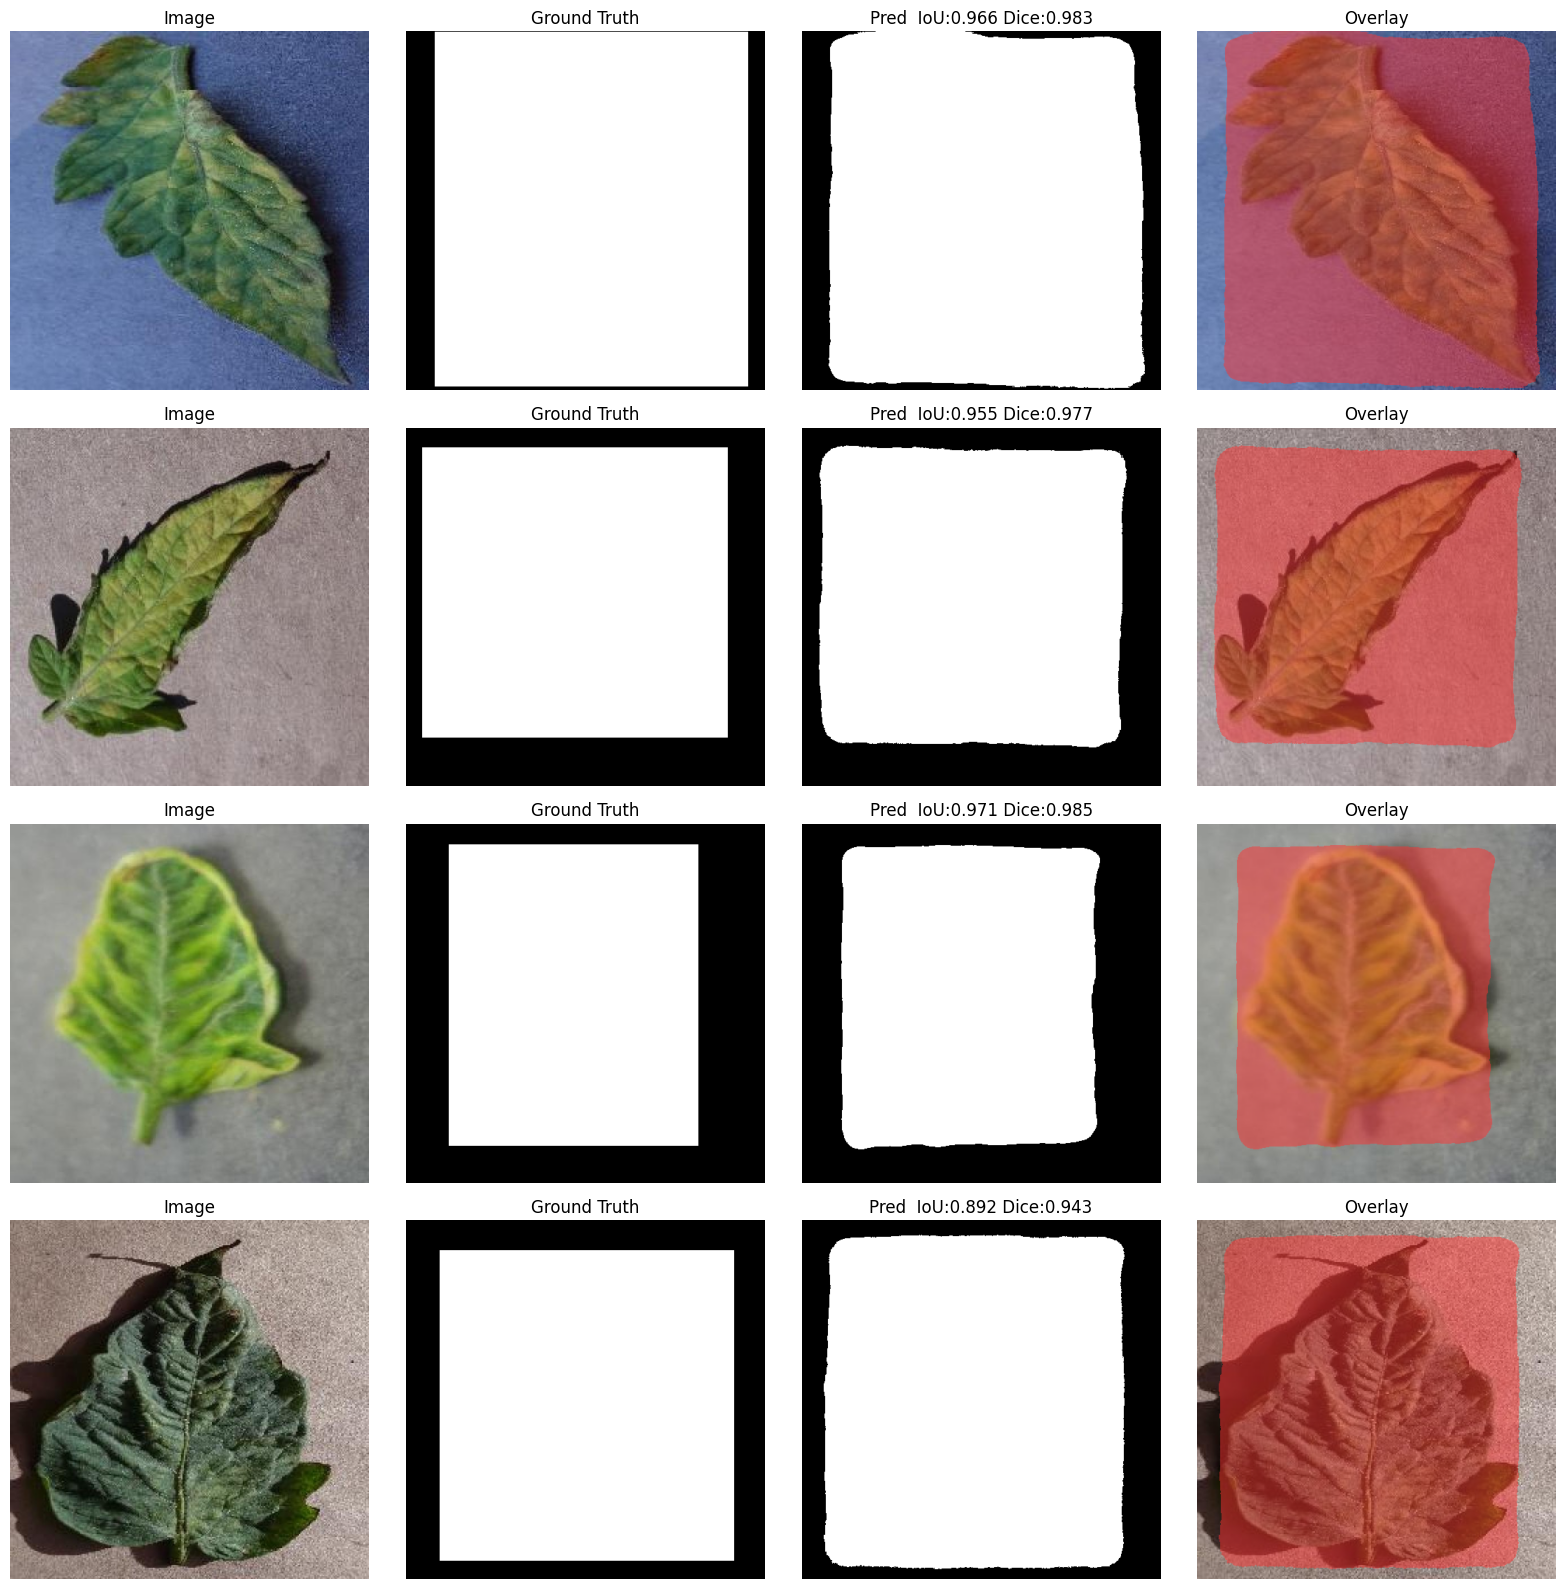

In [10]:
import os
import cv2
import torch
import random
import numpy as np
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = smp.UnetPlusPlus(encoder_name= 'efficientnet-b3', encoder_weights= None, in_channels= 3, classes= 1)

weights_path = 'leaf_seg.pth'
if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f'Loaded weights from: {weights_path}')
else:
    raise FileNotFoundError(f'Could not find {weights_path}. Run the training cell first.')

model = model.to(device)
model.eval()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

samples = random.sample(val_imgs, min(4, len(val_imgs)))

fig, axes = plt.subplots(len(samples), 4, figsize=(16, 4 * len(samples)))
if len(samples) == 1:
    axes = np.expand_dims(axes, 0)

img_dir = '/content/data/processed/images'
mask_dir = '/content/data/processed/masks'

for idx, img_name in enumerate(samples):
    base = os.path.splitext(img_name)[0]

    img = cv2.imread(os.path.join(img_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (512, 512))

    mask = cv2.imread(os.path.join(mask_dir, base + '.png'), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (512, 512))
    gt = (mask > 0).astype(np.float32)

    tensor = torch.tensor((img / 255.0 - mean) / std, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = torch.sigmoid(model(tensor)).squeeze().cpu().numpy()
    pred_bin = (pred > 0.5).astype(np.float32)

    inter = np.sum(pred_bin * gt)
    union = np.sum(pred_bin) + np.sum(gt) - inter
    iou_ = (inter + 1e-6) / (union + 1e-6)
    dice_ = (2 * inter + 1e-6) / (np.sum(pred_bin) + np.sum(gt) + 1e-6)

    overlay = img.copy()
    overlay[pred_bin == 1] = overlay[pred_bin == 1] * 0.5 + np.array([255, 50, 50]) * 0.5

    axes[idx, 0].imshow(img); axes[idx, 0].set_title('Image'); axes[idx, 0].axis('off')
    axes[idx, 1].imshow(gt, cmap='gray'); axes[idx, 1].set_title('Ground Truth'); axes[idx, 1].axis('off')
    axes[idx, 2].imshow(pred_bin, cmap='gray'); axes[idx, 2].set_title(f'Pred  IoU:{iou_:.3f} Dice:{dice_:.3f}'); axes[idx, 2].axis('off')
    axes[idx, 3].imshow(overlay.astype(np.uint8)); axes[idx, 3].set_title('Overlay'); axes[idx, 3].axis('off')

plt.tight_layout()
plt.show()